# Data Loading and Initial Inspection

## Objective
The first step in any data analysis project is to understand the structure and quality of the dataset. This helps identify the available features, data granularity, and any potential issues that may affect downstream analysis.

In this project, the Weekly Sales dataset is loaded and inspected to gain a preliminary understanding of:
- Store-level sales information
- Department-level sales information
- Weekly sales performance
- Holiday impact indicators

This initial inspection serves as the foundation for data preprocessing, anomaly detection, segmentation, and demand forecasting.

In [1]:
# Step 1: Import Libraries
import pandas as pd

# Step 2: Load the sales data
url_sales = "https://raw.githubusercontent.com/YashmanSingh2003/Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting/refs/heads/main/sales%20data-set.csv"
sales_df = pd.read_csv(url_sales)

# Step 3: Display the first 5 rows
sales_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


## Initial Observations

The dataset preview provides an overview of the available information and confirms the data structure.

Key observations include:

- Each record represents weekly sales data for a specific store and department.
- The dataset contains store identifiers and department identifiers, allowing granular analysis.
- Weekly sales values serve as the primary target variable for forecasting and performance evaluation.
- The **IsHoliday** feature indicates whether a given week includes a holiday period, which may significantly influence consumer purchasing behavior.
- The dataset appears to be organized at the Store–Department–Week level, making it suitable for time-series analysis, anomaly detection, and demand forecasting.

This inspection confirms that the dataset contains the necessary information required for sales trend analysis and predictive modeling.

# Dataset Structure and Data Quality Assessment

## Objective

Before performing any advanced analysis, it is important to evaluate the dataset's structure, completeness, and overall quality. Understanding the data types, missing values, and statistical characteristics helps identify potential issues that could affect the reliability of subsequent analyses.

The following checks are performed:

- Identify missing or null values across all columns.
- Verify data types of each feature.
- Generate descriptive statistics for numerical variables.
- Detect unusual values that may require further investigation.

These checks provide a foundation for effective data preprocessing and feature engineering.

In [2]:
# Step 1: Check for missing values
print("Missing Values:\n")
print(sales_df.isnull().sum())

# Step 2: Check column data types
print("\nData Types:\n")
print(sales_df.dtypes)

# Step 3: View summary statistics of numerical features
print("\nDescriptive Statistics:\n")
print(sales_df.describe())

Missing Values:

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Data Types:

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

Descriptive Statistics:

               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000


## Findings and Interpretation

### Missing Values

The missing value assessment indicates that the sales dataset is complete, with no missing values detected in the available columns. This reduces the risk of bias introduced by missing data and simplifies the preprocessing stage.

### Data Types

The dataset contains a combination of:

- Numerical variables such as Weekly_Sales, Store, and Dept.
- A date variable that will be converted into a datetime format for time-based analysis.
- A holiday indicator (IsHoliday) that can be used to evaluate seasonal and holiday-driven sales behavior.

Proper data type conversion is essential for accurate feature engineering and time-series analysis.

### Descriptive Statistics

The statistical summary provides an overview of the distribution of Weekly Sales values.

Key observations include:

- Weekly sales exhibit substantial variation across stores and departments.
- The maximum sales value is significantly higher than the average, indicating the presence of high-performing periods or departments.
- Negative sales values are present in the dataset, which may represent product returns, corrections, or recording adjustments.
- The large gap between minimum and maximum sales values suggests potential outliers that should be investigated during anomaly detection.

### Business Implications

The wide sales range highlights the diverse performance levels across stores and departments. Understanding these variations will be critical for:

- Detecting anomalous sales patterns.
- Segmenting stores based on performance characteristics.
- Building accurate demand forecasting models.
- Designing inventory and marketing strategies tailored to different store profiles.

The presence of unusually high and negative sales values warrants further investigation in the anomaly detection phase to ensure reliable analytical outcomes.

## Date Conversion and Data Sorting

To prepare the dataset for time-series analysis, the Date column is converted to datetime format. The data is then sorted by Store, Department, and Date to ensure that sales records follow a chronological order.

In [3]:
# Step 1: Convert 'Date' column to datetime with correct format
sales_df['Date'] = pd.to_datetime(sales_df['Date'], dayfirst=True)

# Step 2: Sort by Store, Dept, and Date
sales_df = sales_df.sort_values(by=['Store', 'Dept', 'Date'])

# Step 3: Confirm changes
print(sales_df.dtypes)
sales_df.head()

Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


### Key Observation

The Date column has been successfully converted to datetime format, enabling time-based analysis and feature extraction. Sorting the data ensures that weekly sales trends can be analyzed accurately across stores and departments.

## Data Integration

The sales, store, and feature datasets are combined into a single dataframe. This creates a comprehensive dataset containing sales records, store attributes, and external factors required for deeper analysis and predictive modeling.

In [4]:
# Step 1: Load the remaining datasets
url_stores = "https://raw.githubusercontent.com/YashmanSingh2003/Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting/refs/heads/main/stores%20data-set.csv"
stores_df = pd.read_csv(url_stores)
url_features = "https://raw.githubusercontent.com/YashmanSingh2003/Integrated-Retail-Analytics-for-Store-Optimization-and-Demand-Forecasting/refs/heads/main/Features%20data%20set.csv"
features_df = pd.read_csv(url_features)

# Step 2: Convert 'Date' in features_df to datetime
features_df['Date'] = pd.to_datetime(features_df['Date'], dayfirst=True)

# Step 3: Merge sales_df with stores_df
merged_df = pd.merge(sales_df, stores_df, on='Store', how='left')

# Step 4: Merge the result with features_df
merged_df = pd.merge(merged_df, features_df, on=['Store', 'Date'], how='left')

# Step 5: Display the shape and first few rows
print("Merged Data Shape:", merged_df.shape)
merged_df.head()

Merged Data Shape: (421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


### Key Observation

The merge operation successfully combines sales data with store information and external variables such as fuel price, CPI, unemployment, and markdown data. This unified dataset will serve as the primary source for anomaly detection, segmentation, demand forecasting, and business strategy analysis.

## Missing Value Treatment

Before proceeding with analysis, missing values are examined and handled appropriately. Since missing values in the MarkDown columns typically indicate that no promotional markdown was applied, they are replaced with 0 to preserve business meaning and maintain data consistency.

In [5]:
# Step 1: Check total missing values per column
print("Missing Values in Merged Data:\n")
print(merged_df.isnull().sum())

# Step 2: Fill missing values in MarkDown columns with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
merged_df[markdown_cols] = merged_df[markdown_cols].fillna(0)

# Step 3: Print missing values again to verify
print("\nAfter Filling MarkDown Columns:\n")
print(merged_df.isnull().sum())

Missing Values in Merged Data:

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
dtype: int64

After Filling MarkDown Columns:

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday_x     0
Type            0
Size            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
dtype: int64


### Key Observation

A large number of missing values were found in the MarkDown features. These values were replaced with 0, assuming that no markdown activity occurred during those periods. After treatment, the dataset is free from missing values in the promotional variables and is ready for further analysis.

## Anomaly Detection in Weekly Sales

Identifying unusual sales patterns is important for understanding exceptional business events and improving forecasting accuracy. In this step, a boxplot is used for visual inspection, while the IQR (Interquartile Range) method is used to systematically detect sales anomalies.

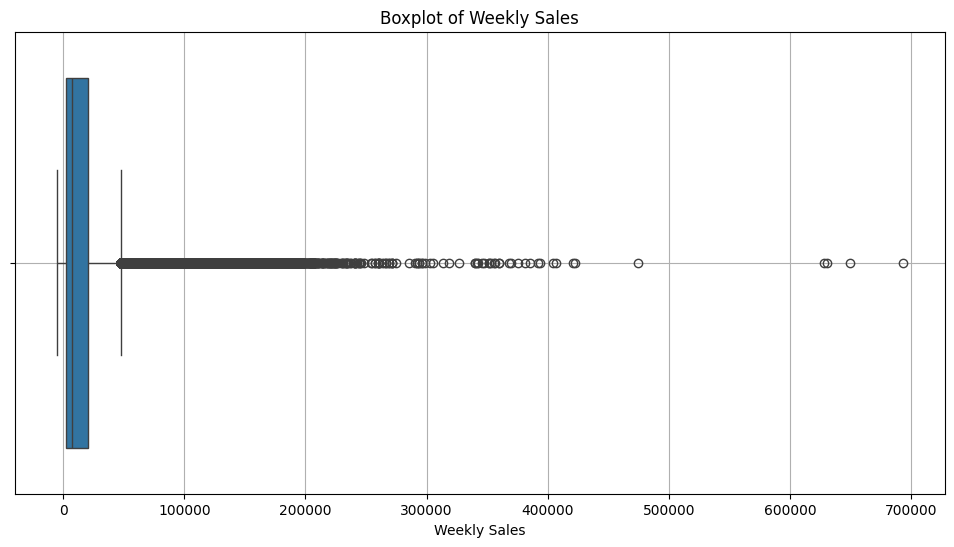

Total anomalies detected: 35521


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create a boxplot of Weekly Sales to detect outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=merged_df, x='Weekly_Sales')
plt.title('Boxplot of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.grid(True)
plt.show()

# Step 2: Detect outliers using IQR method
Q1 = merged_df['Weekly_Sales'].quantile(0.25)
Q3 = merged_df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Create anomaly column
merged_df['Is_Anomaly'] = ((merged_df['Weekly_Sales'] < lower_bound) |
                           (merged_df['Weekly_Sales'] > upper_bound))

# Step 4: Print how many anomalies detected
print("Total anomalies detected:", merged_df['Is_Anomaly'].sum())

### Key Observation

The boxplot reveals the presence of several extreme sales values outside the normal range. Using the IQR method, these observations are flagged as anomalies.

Possible reasons for these unusual sales patterns include:

- Holiday shopping periods
- Promotional markdown campaigns
- Seasonal demand spikes
- Product returns or sales adjustments

These anomalies will be analyzed further to determine whether they represent genuine business events or data irregularities.

## Time-Based Sales Trend Analysis

To identify long-term trends and seasonal patterns, weekly sales are aggregated over time and visualized using a time-series plot. This helps understand how sales fluctuate across different periods and highlights the impact of holidays and seasonal demand.

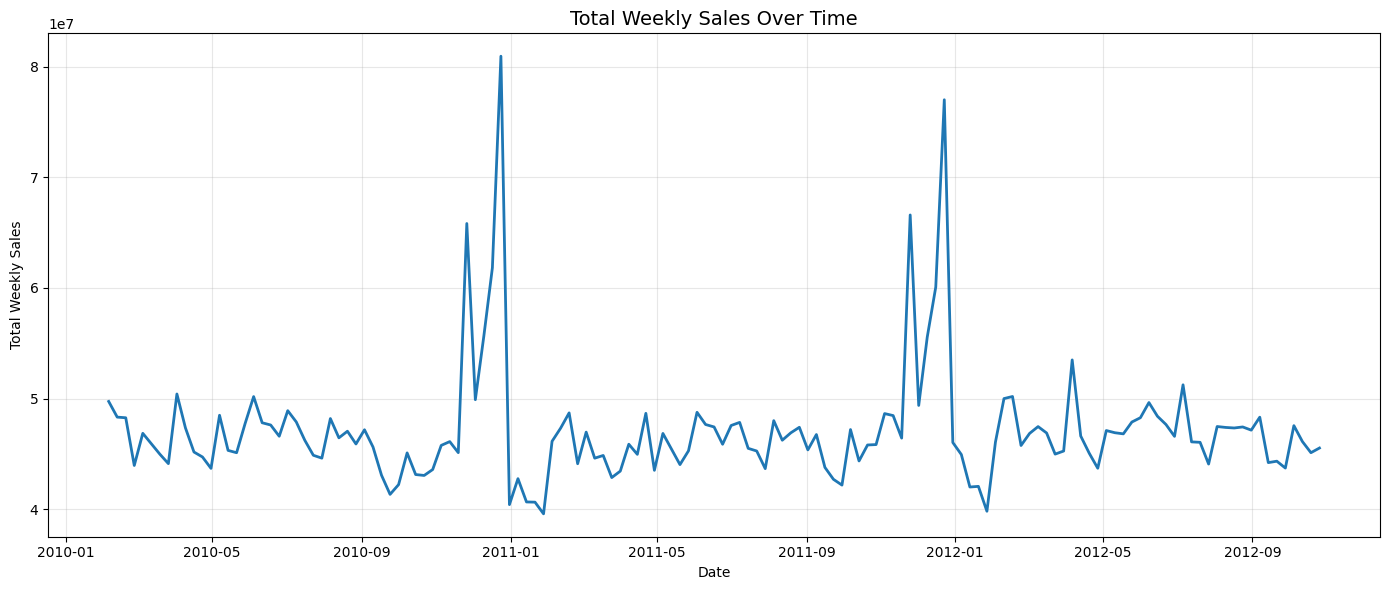

In [7]:
# Step 1: Ensure Date column is in datetime format
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Step 2: Aggregate total sales by date
weekly_sales_trend = (
    merged_df.groupby('Date')['Weekly_Sales']
    .sum()
    .reset_index()
)

# Step 3: Visualize sales trend over time
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=weekly_sales_trend,
    x='Date',
    y='Weekly_Sales',
    linewidth=2
)

plt.title('Total Weekly Sales Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Observation

The sales trend demonstrates noticeable fluctuations over time, indicating the presence of seasonal demand patterns. Several sales peaks likely correspond to holiday shopping periods, while lower sales periods may reflect post-holiday demand declines. These findings suggest that time-related factors play an important role in forecasting future sales.

## Holiday vs Non-Holiday Sales Analysis

Holiday periods often have a significant impact on customer purchasing behavior. This analysis compares sales during holiday weeks and non-holiday weeks to understand the influence of special events on overall store performance.

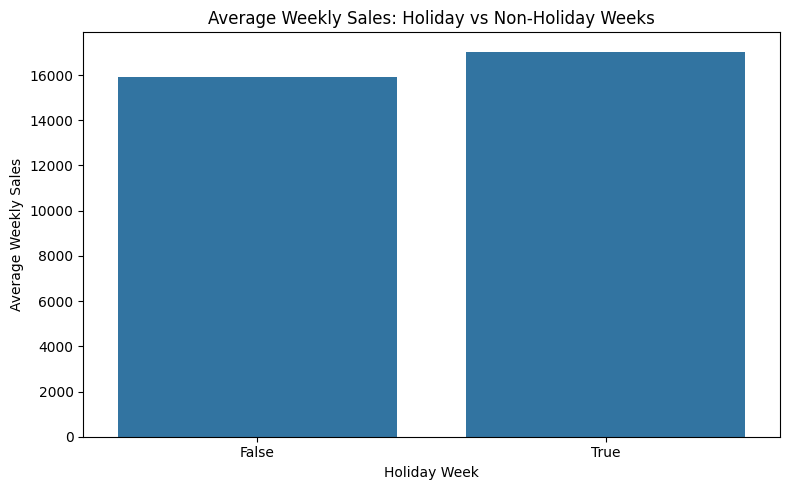

   IsHoliday_x  Weekly_Sales
0        False  15901.445069
1         True  17035.823187


In [8]:
# Step 1: Aggregate sales by holiday status
holiday_sales = (
    merged_df.groupby('IsHoliday_x')['Weekly_Sales']
    .mean()
    .reset_index()
)

# Step 2: Visualize average sales comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=holiday_sales,
    x='IsHoliday_x',
    y='Weekly_Sales'
)

plt.title('Average Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.xlabel('Holiday Week')
plt.ylabel('Average Weekly Sales')

plt.tight_layout()
plt.show()

# Step 3: Display values
print(holiday_sales)

### Key Observation

The comparison highlights the impact of holiday periods on sales performance. Holiday weeks generally exhibit different sales behavior compared to non-holiday weeks, reflecting changes in customer demand and purchasing patterns. This suggests that holiday indicators should be included as an important feature in demand forecasting models.

## Feature Engineering

Feature engineering is performed to create additional variables that can improve analytical insights and model performance. Date-based features capture seasonal patterns, while rolling averages help smooth short-term fluctuations and reveal underlying sales trends.

In [10]:
# Step 1: Extract date-based features
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Week'] = merged_df['Date'].dt.isocalendar().week

# Step 2: Sort data chronologically
merged_df = merged_df.sort_values(['Store', 'Dept', 'Date'])

# Step 3: Create a 4-week rolling average of sales
merged_df['Weekly_Sales_RollingAvg'] = (
    merged_df.groupby(['Store', 'Dept'])['Weekly_Sales']
    .transform(lambda x: x.rolling(window=4, min_periods=1).mean())
)

# Step 4: Display sample results
merged_df[
    ['Date', 'Store', 'Dept', 'Weekly_Sales',
     'Weekly_Sales_RollingAvg']
].head(10)

,Date,Store,Dept,Weekly_Sales,Weekly_Sales_RollingAvg
0,2010-02-05,1,1,24924.50,24924.500000
1,2010-02-12,1,1,46039.49,35481.995000
2,2010-02-19,1,1,41595.55,37519.846667
3,2010-02-26,1,1,19403.54,32990.770000
4,2010-03-05,1,1,21827.90,32216.620000
5,2010-03-12,1,1,21043.39,25967.595000
6,2010-03-19,1,1,22136.64,21102.867500
7,2010-03-26,1,1,26229.21,22809.285000
8,2010-04-02,1,1,57258.43,31666.917500
9,2010-04-09,1,1,42960.91,37146.297500


### Key Observation

New time-based features (Year, Month, and Week) have been created to capture seasonal and temporal sales patterns. Additionally, a 4-week rolling average was generated to smooth sales fluctuations and provide a clearer view of underlying demand trends. These engineered features can improve forecasting accuracy and support deeper trend analysis.

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset. Understanding these relationships is useful for feature selection, detecting multicollinearity, and identifying factors that may influence weekly sales.

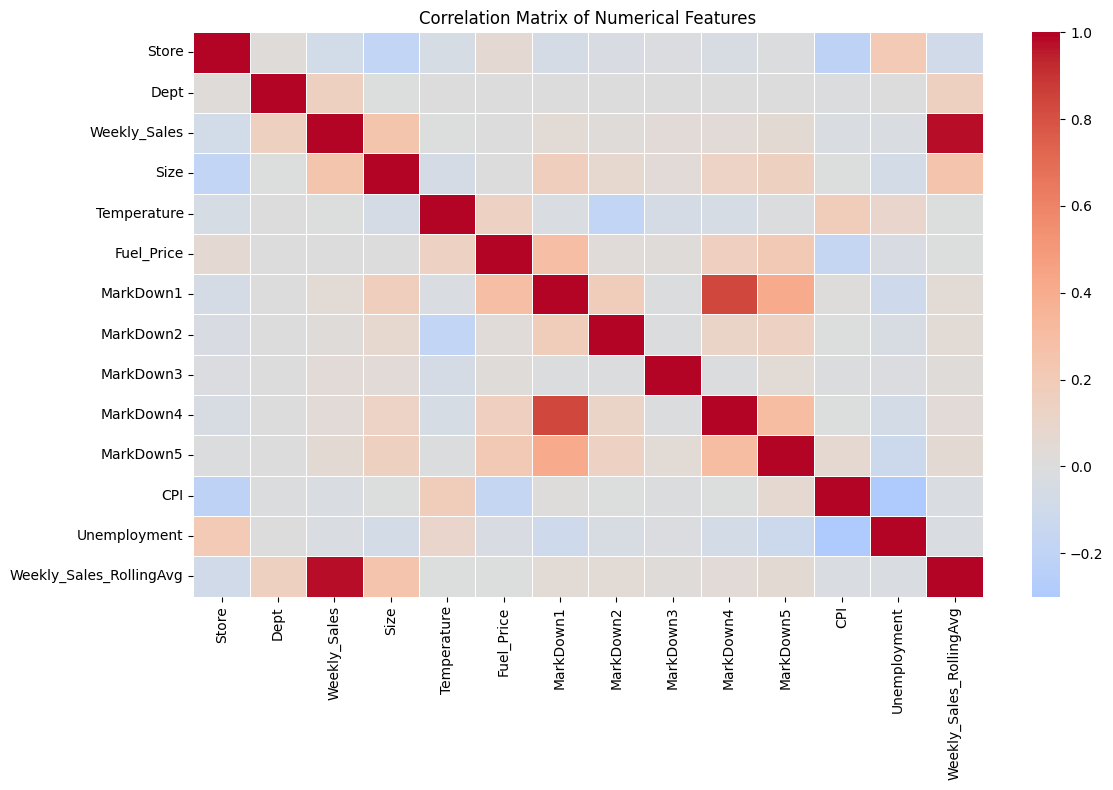

In [12]:
# Step 1: Select numerical features
numeric_features = merged_df.select_dtypes(include=['float64', 'int64'])

# Step 2: Compute correlation matrix
correlation_matrix = numeric_features.corr()

# Step 3: Visualize correlations
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### Key Observation

The correlation matrix provides insight into how numerical variables relate to each other and to Weekly Sales. Strong positive or negative correlations may indicate important drivers of sales performance, while highly correlated predictor variables can signal potential multicollinearity. These insights help guide feature selection for forecasting and predictive modeling.

## Encoding Categorical Variables

Machine learning models require numerical input data. Therefore, categorical and boolean features are converted into numerical representations while preserving the information they contain.

In [13]:
# Step 1: Identify categorical features
categorical_cols = merged_df.select_dtypes(include=['object', 'bool']).columns
print("Categorical Columns:\n", categorical_cols)

# Step 2: Convert boolean columns to integers
bool_cols = merged_df.select_dtypes(include='bool').columns
merged_df[bool_cols] = merged_df[bool_cols].astype(int)

# Step 3: Apply one-hot encoding to Store Type
merged_df = pd.get_dummies(
    merged_df,
    columns=['Type'],
    drop_first=True
)

# Preview encoded columns
merged_df.head()

Categorical Columns:
 Index(['IsHoliday_x', 'Type', 'IsHoliday_y', 'Is_Anomaly'], dtype='object')


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,CPI,Unemployment,IsHoliday_y,Is_Anomaly,Year,Month,Week,Weekly_Sales_RollingAvg,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,151315,42.31,2.572,0.0,0.0,...,211.096358,8.106,0,0,2010,2,5,24924.500000,False,False
1,1,1,2010-02-12,46039.49,1,151315,38.51,2.548,0.0,0.0,...,211.242170,8.106,1,0,2010,2,6,35481.995000,False,False
2,1,1,2010-02-19,41595.55,0,151315,39.93,2.514,0.0,0.0,...,211.289143,8.106,0,0,2010,2,7,37519.846667,False,False
3,1,1,2010-02-26,19403.54,0,151315,46.63,2.561,0.0,0.0,...,211.319643,8.106,0,0,2010,2,8,32990.770000,False,False
4,1,1,2010-03-05,21827.90,0,151315,46.50,2.625,0.0,0.0,...,211.350143,8.106,0,0,2010,3,9,32216.620000,False,False


### Key Observation

Boolean variables were converted into binary values (0 and 1), and the store Type feature was transformed using one-hot encoding. This ensures that categorical information can be effectively utilized by machine learning algorithms without introducing unintended ordinal relationships.

## Feature Scaling

Numerical features often exist on different scales. Feature scaling standardizes these variables to ensure that no single feature disproportionately influences machine learning models due to its magnitude.

In [14]:
from sklearn.preprocessing import StandardScaler

# Step 1: Define numerical features to scale
scale_cols = [
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Weekly_Sales_RollingAvg'
]

# Step 2: Initialize scaler
scaler = StandardScaler()

# Step 3: Apply standardization
merged_df[scale_cols] = scaler.fit_transform(merged_df[scale_cols])

# Step 4: Preview scaled features
merged_df[scale_cols].head()

,Size,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Weekly_Sales_RollingAvg
0,0.239209,-0.963798,-1.720834,1.018774,0.078201,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,0.401313
1,0.239209,-1.169783,-1.773177,1.022498,0.078201,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,0.875796
2,0.239209,-1.092810,-1.847330,1.023697,0.078201,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,0.967382
3,0.239209,-0.729625,-1.744825,1.024476,0.078201,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,0.763833
4,0.239209,-0.736672,-1.605243,1.025255,0.078201,-0.427943,-0.173069,-0.084662,-0.278117,-0.395181,0.729041


### Key Observation

The selected numerical features have been standardized using StandardScaler. After scaling, the variables are centered around a mean of 0 with a standard deviation of 1. This ensures that features with larger numerical ranges do not dominate the learning process and improves the performance of many machine learning algorithms.

## Train-Test Split

To evaluate model performance on unseen data, the dataset is divided into training and testing sets. The training set is used to learn patterns from the data, while the test set is reserved for assessing the model's predictive capability.

In [15]:
from sklearn.model_selection import train_test_split

# Step 1: Define target and features
target = 'Weekly_Sales'

drop_cols = ['Date', 'Weekly_Sales', 'Is_Anomaly']

X = merged_df.drop(columns=drop_cols)
y = merged_df[target]

# Step 2: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 3: Display dataset shapes
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (337256, 20)
Test set shape: (84314, 20)


### Key Observation

The dataset was split into 80% training data and 20% testing data. The training set contains 337,256 records, while the test set contains 84,314 records. This split provides sufficient data for model training while maintaining a large and representative test set for performance evaluation.

## Baseline Demand Forecasting Model

A Linear Regression model is used as a baseline forecasting model. Establishing a baseline allows future models to be compared against a simple and interpretable approach before exploring more advanced algorithms.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Step 2: Generate predictions
y_pred = lr_model.predict(X_test)

# Step 3: Evaluate performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Performance
-----------------------------------
Mean Absolute Error (MAE): 1693.66
Mean Squared Error (MSE): 24388776.07
R² Score: 0.9532


### Model Performance

The Linear Regression model achieved an R² score of **0.9532**, meaning it explains approximately **95.3% of the variation in weekly sales**. This indicates a strong relationship between the selected features and the target variable.

Key Metrics:

- **MAE:** 1,693.66
- **MSE:** 24,388,776.07
- **R² Score:** 0.9532

The high R² value suggests that the engineered features, store characteristics, markdown information, and external economic indicators are effective predictors of weekly sales. As a baseline model, Linear Regression provides a strong benchmark for evaluating more advanced forecasting techniques.

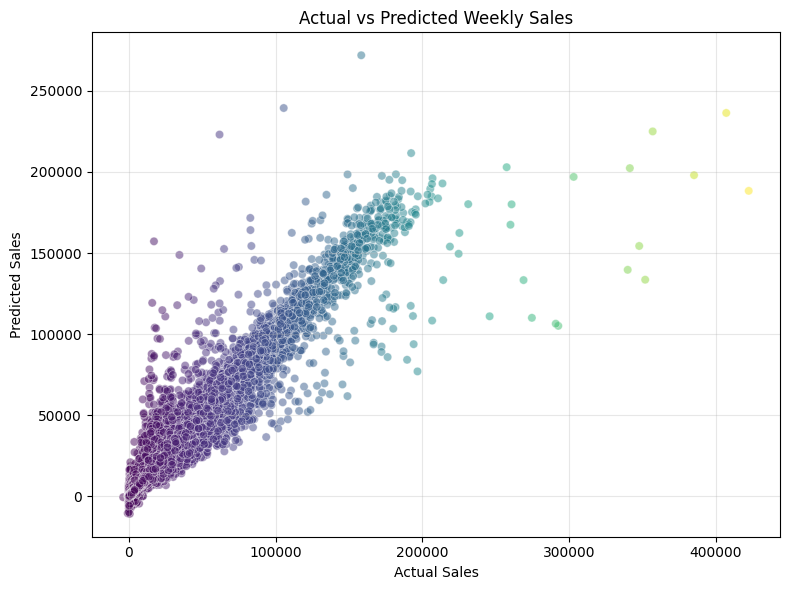

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=y_test,
    palette='viridis',
    alpha=0.5,
    legend=False
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Prediction Analysis

The scatter plot compares actual sales with model predictions. Points closer to the diagonal indicate more accurate predictions. The concentration of points around the expected trend line further confirms the model's strong predictive performance.

## Advanced Demand Forecasting with Random Forest

To improve forecasting accuracy, a Random Forest Regressor is trained. Unlike Linear Regression, Random Forest can capture complex and non-linear relationships between sales and influencing factors, making it well-suited for retail demand forecasting.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 1: Initialize and train the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Step 2: Generate predictions
y_pred_rf = rf_model.predict(X_test)

# Step 3: Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

Random Forest Performance
-----------------------------------
Mean Absolute Error (MAE): 1446.92
Mean Squared Error (MSE): 14299629.13
R² Score: 0.9726


### Model Performance

The Random Forest model achieved an **R² score of 0.9726**, outperforming the Linear Regression model and explaining approximately **97.3% of the variation in weekly sales**.

Key Metrics:

- **MAE:** 1,446.92
- **MSE:** 14,299,629.13
- **R² Score:** 0.9726

Compared to Linear Regression, Random Forest produced lower prediction errors and a higher R² score, indicating that it captures sales patterns more effectively. This suggests that non-linear relationships exist within the data and can be leveraged to improve forecasting accuracy.

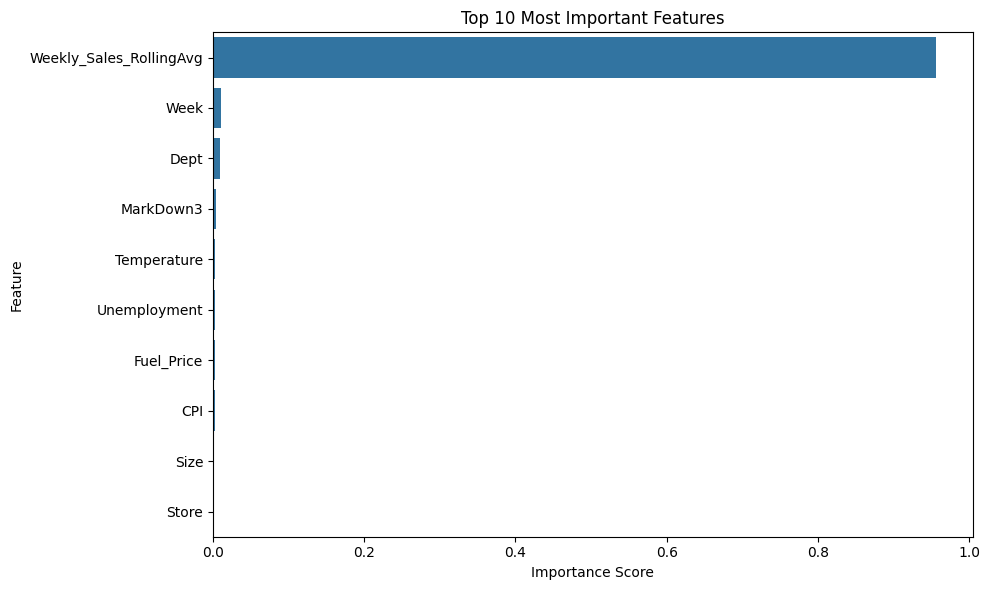

In [20]:
# Feature Importance Analysis

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

### Feature Importance Insights

The feature importance analysis identifies the variables that contribute most to sales predictions. Understanding these drivers helps businesses focus on the factors that have the greatest impact on demand and supports more informed inventory and marketing decisions.

## Feature Importance Analysis

Understanding which factors most influence sales is essential for business decision-making. Random Forest provides feature importance scores that help identify the key drivers of weekly sales and support data-driven inventory, pricing, and marketing strategies.

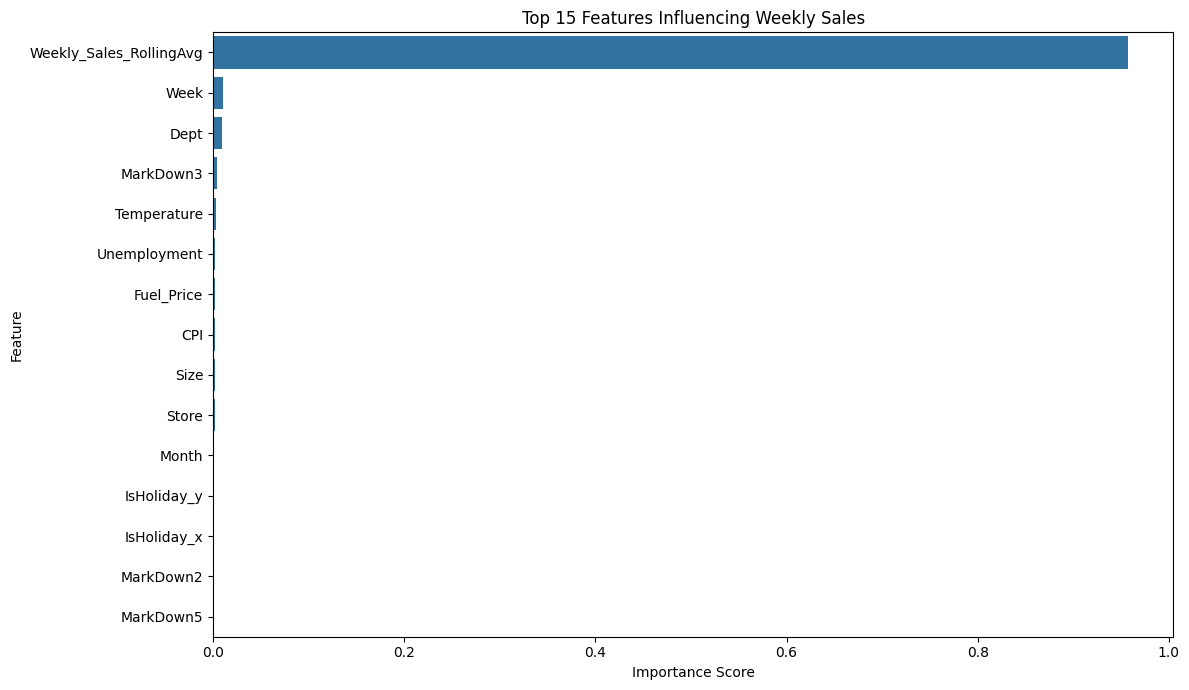

,Feature,Importance
17,Weekly_Sales_RollingAvg,0.956861
16,Week,0.010212
1,Dept,0.009148
8,MarkDown3,0.004023
4,Temperature,0.002791
12,Unemployment,0.002380
5,Fuel_Price,0.002242
11,CPI,0.002130
3,Size,0.001935
0,Store,0.001818


In [21]:
# Step 1: Extract feature importances
importances = rf_model.feature_importances_
features = X_train.columns

# Step 2: Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Step 3: Sort and select top features
importance_df = (
    importance_df
    .sort_values(by='Importance', ascending=False)
    .head(15)
)

# Step 4: Visualize feature importance
plt.figure(figsize=(12, 7))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Features Influencing Weekly Sales')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# Optional: Display values
importance_df

### Key Observation

The feature importance analysis highlights the variables that contribute most to sales predictions. Features with higher importance scores have a greater influence on forecasting performance and can be considered key business drivers.

These insights help identify which operational, promotional, and economic factors have the strongest impact on weekly sales and can support more effective business planning and decision-making.

## Store Segmentation Using K-Means Clustering

To better understand differences in store performance, K-Means clustering is used to segment stores based on sales, store size, and economic indicators. This helps identify groups of stores with similar characteristics and supports targeted business strategies.

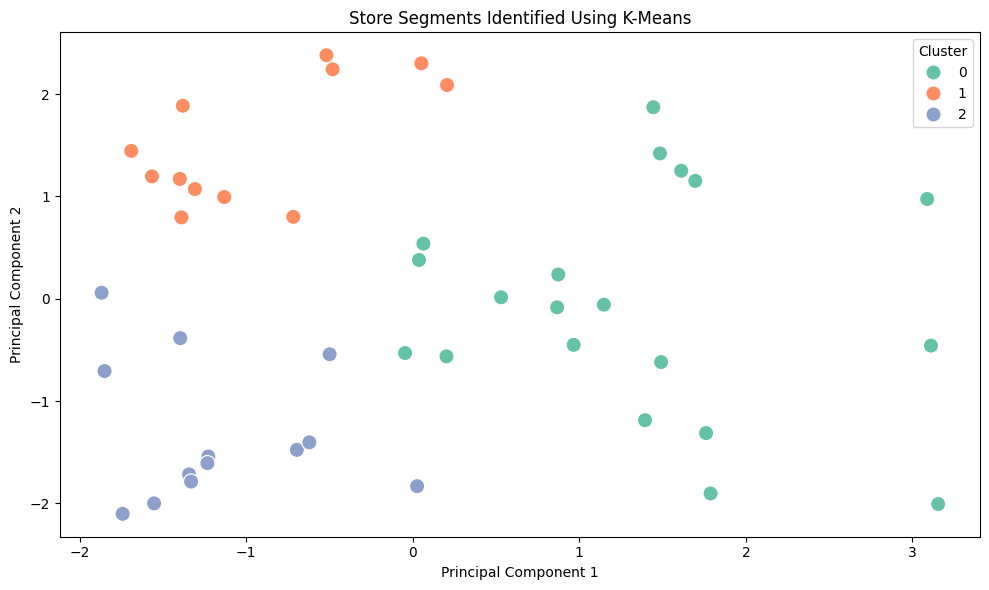

,Store,Weekly_Sales,Size,CPI,Unemployment,Fuel_Price,PCA1,PCA2
Cluster,,,,,,,,
0,26.850000,14842.486566,-0.168657,-0.906916,0.425071,0.291961,1.333306,-0.066576
1,17.833333,23301.534848,1.011529,0.605692,-0.289210,-0.216210,-0.943965,1.530690
2,21.846154,9095.845212,-1.039829,0.870985,-0.321912,-0.251923,-1.179887,-1.310520


In [22]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Step 1: Aggregate store-level features
store_features = (
    merged_df.groupby('Store')
    .agg({
        'Weekly_Sales': 'mean',
        'Size': 'first',
        'CPI': 'mean',
        'Unemployment': 'mean',
        'Fuel_Price': 'mean'
    })
    .reset_index()
)

# Step 2: Scale features
scaled_store_features = scaler.fit_transform(
    store_features.drop(columns=['Store'])
)

# Step 3: Apply K-Means clustering
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

store_features['Cluster'] = kmeans.fit_predict(
    scaled_store_features
)

# Step 4: Reduce dimensions for visualization
pca = PCA(n_components=2)

reduced = pca.fit_transform(
    scaled_store_features
)

store_features['PCA1'] = reduced[:, 0]
store_features['PCA2'] = reduced[:, 1]

# Step 5: Visualize clusters
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=store_features,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2',
    s=120
)

plt.title('Store Segments Identified Using K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

# Step 6: Cluster summary
cluster_summary = store_features.groupby('Cluster').mean()

cluster_summary

### Cluster Interpretation

**Cluster 0**
- Highest average weekly sales among all segments.
- Represents high-performing stores with strong revenue generation.

**Cluster 1**
- Medium sales performance.
- Stores may benefit from targeted promotional strategies to improve growth.

**Cluster 2**
- Lowest average sales levels.
- May require inventory optimization and localized marketing efforts.

These segments provide a foundation for personalized business strategies rather than applying a single approach to all stores.

### Key Observation

K-Means clustering successfully grouped stores into three distinct segments based on sales performance, store size, and economic factors.

The visualization shows clear separation between store groups, indicating that stores exhibit different operational and market characteristics. These segments can be used to develop targeted inventory planning, promotional campaigns, and resource allocation strategies.

By analyzing cluster-level averages, we can better understand the unique characteristics and performance patterns of each store segment.

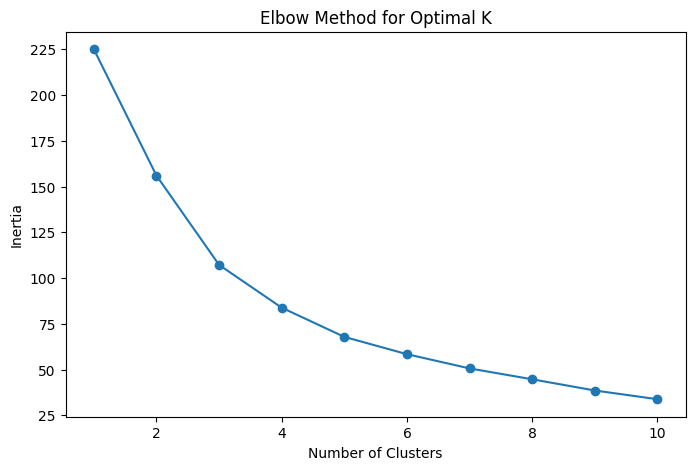

In [23]:
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_store_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

## Segmentation Quality Evaluation

After creating store segments, it is important to assess the quality of the clustering results. Silhouette Score and Inertia are used to evaluate how well the stores have been grouped and whether the identified segments are meaningful.

In [24]:
from sklearn.metrics import silhouette_score

# Step 1: Calculate Silhouette Score
sil_score = silhouette_score(
    scaled_store_features,
    store_features['Cluster']
)

print(f"Silhouette Score: {sil_score:.4f}")

# Step 2: Display Inertia
print(f"Inertia: {kmeans.inertia_:.2f}")

Silhouette Score: 0.3345
Inertia: 107.18


### Key Observation

- **Silhouette Score:** 0.3345
- **Inertia:** 107.18

The Silhouette Score indicates a moderate clustering structure, suggesting that the store segments are reasonably separated while still reflecting some overlap between groups. This is common in real-world retail datasets where store characteristics often share similarities.

The relatively low Inertia value indicates that stores within each cluster are grouped closely together, demonstrating good internal consistency.

Overall, the clustering results provide meaningful and actionable store segments that can support targeted marketing, inventory planning, and operational decision-making.

In [25]:
if sil_score > 0.5:
    print("Strong cluster separation")
elif sil_score > 0.25:
    print("Moderate cluster separation")
else:
    print("Weak cluster separation")

Moderate cluster separation


## Market Basket-Style Analysis

Since individual customer transaction data is unavailable, a proxy market basket analysis is performed using department-level sales patterns. Departments that frequently experience high sales during the same store-week periods may indicate potential product associations and cross-selling opportunities.

/tmp/ipykernel_29643/1734555267.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


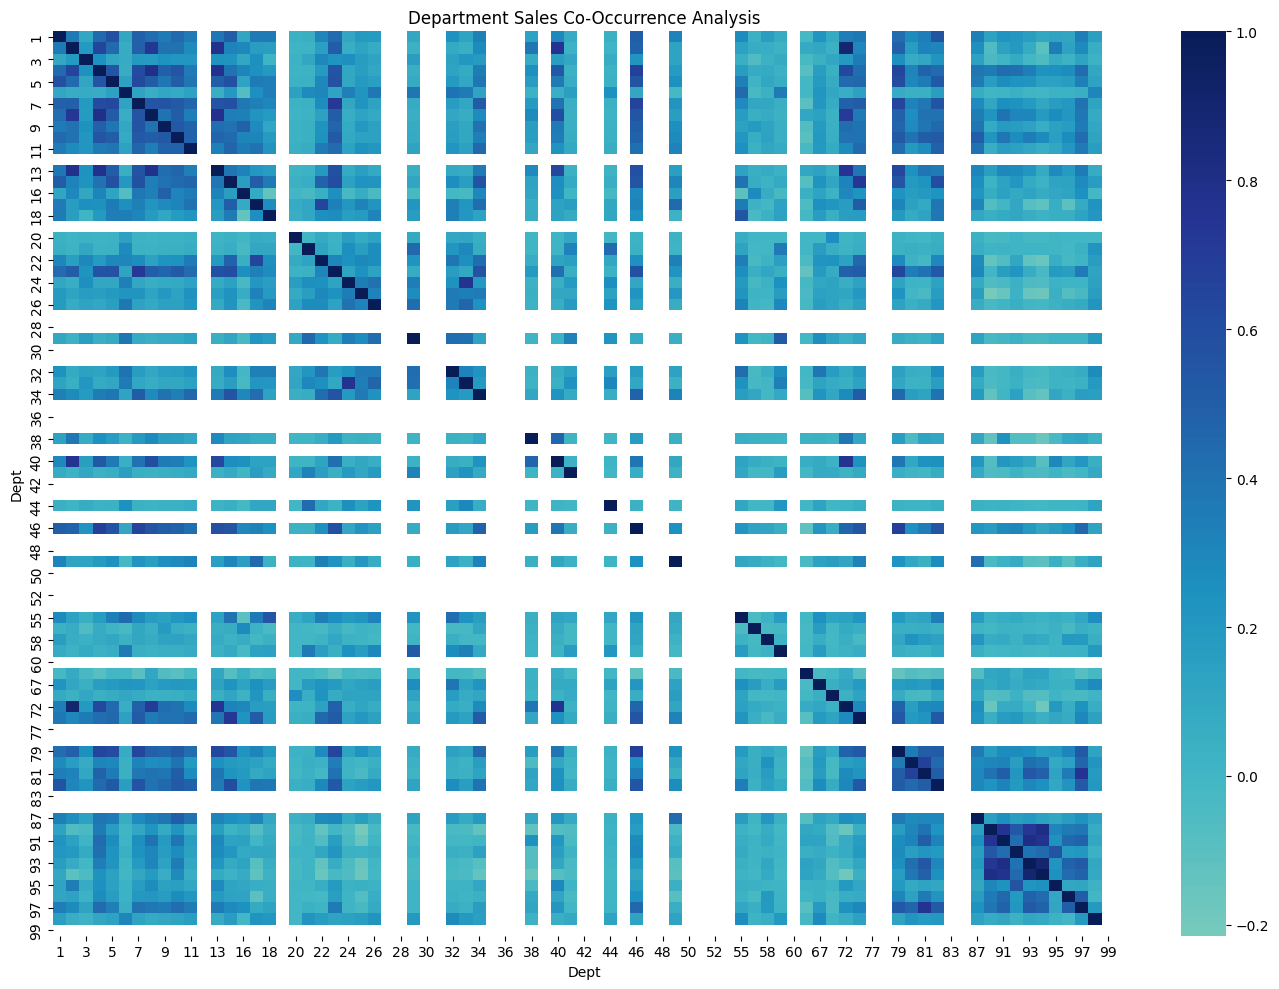

In [26]:
# Step 1: Create a high-sales indicator
dept_sales = merged_df.copy()

dept_sales['High_Sales'] = (
    dept_sales['Weekly_Sales'] >
    dept_sales['Weekly_Sales'].quantile(0.75)
)

# Step 2: Create Store-Date vs Department matrix
basket_df = (
    dept_sales.pivot_table(
        index=['Store', 'Date'],
        columns='Dept',
        values='High_Sales',
        aggfunc='max'
    )
    .fillna(0)
)

# Step 3: Compute department correlations
corr_matrix = basket_df.corr()

# Step 4: Visualize co-occurrence patterns
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap='YlGnBu',
    center=0
)

plt.title('Department Sales Co-Occurrence Analysis')

plt.tight_layout()
plt.show()

### Key Observation

The heatmap highlights relationships between departments based on the frequency with which they experience high sales during the same store-week periods.

Departments with stronger positive correlations may represent complementary purchasing patterns and could be targeted through:

- Cross-selling initiatives
- Bundled promotions
- Joint marketing campaigns
- Coordinated inventory planning

Although this is not a traditional market basket analysis, it provides valuable insights into potential department-level associations within the retail environment.

In [27]:
# Find strongest department relationships

corr_pairs = corr_matrix.unstack()

corr_pairs = (
    corr_pairs[corr_pairs < 1]
    .sort_values(ascending=False)
)

corr_pairs.head(10)

,,0
Dept,Dept,
94,93,0.896174
93,94,0.896174
2,72,0.892400
72,2,0.892400
94,90,0.808924
90,94,0.808924
91,93,0.801309
93,91,0.801309
4,8,0.789516


### Business Insight

The strongest department pairs represent areas where sales tend to increase together. These combinations may be suitable candidates for bundled promotions, product placement strategies, and coordinated marketing efforts to increase overall sales performance.

# Strategic Recommendations

Based on the analysis, forecasting models, store segmentation, and department-level sales patterns, the following business recommendations are proposed.

### 1. Demand Forecasting and Inventory Planning
- Use the Random Forest forecasting model to anticipate weekly sales demand.
- Increase inventory allocation for high-demand departments during peak periods.
- Reduce stock levels during expected low-demand periods to minimize holding costs.

### 2. Store-Specific Strategies
- High-performing store clusters should focus on inventory availability and premium product offerings.
- Lower-performing stores may benefit from localized promotions and targeted marketing campaigns.
- Tailor business strategies according to store segment characteristics rather than applying a uniform approach.

### 3. Promotional Optimization
- MarkDown variables were identified as important sales drivers.
- Schedule promotional campaigns around holidays and seasonal demand peaks.
- Evaluate markdown effectiveness by department and store segment.

### 4. Economic Factor Monitoring
- Economic indicators such as CPI, Fuel Price, and Unemployment influence sales performance.
- Adjust promotional intensity and inventory planning based on regional economic conditions.

### 5. Cross-Selling Opportunities
- Departments exhibiting strong co-occurrence patterns should be promoted together.
- Bundle related products and optimize store layouts to encourage complementary purchases.

### 6. Personalized Marketing
- Develop segment-specific marketing campaigns.
- Apply targeted markdown strategies based on store performance and customer demand patterns.
- Allocate marketing budgets according to segment growth potential.

# Project Summary

## Integrated Retail Analytics for Store Optimization and Demand Forecasting

This project applied data analytics and machine learning techniques to improve retail decision-making through demand forecasting, anomaly detection, store segmentation, and sales pattern analysis.

### Key Activities Performed

- Integrated sales, store, and external feature datasets into a unified analytical framework.
- Conducted data cleaning, preprocessing, and feature engineering.
- Identified sales anomalies and seasonal trends through exploratory analysis.
- Evaluated the impact of holidays, markdowns, and economic indicators on sales performance.
- Built demand forecasting models using Linear Regression and Random Forest Regression.
- Segmented stores using K-Means clustering and evaluated segment quality using Silhouette Score.
- Performed a market basket-style analysis to identify department-level sales associations.
- Developed business recommendations for inventory optimization, marketing, and store management.

### Key Results

- The Random Forest model achieved the best forecasting performance with an R² score of **0.9726**, outperforming Linear Regression.
- Store segmentation revealed distinct groups with different operational and sales characteristics.
- Promotional markdowns and historical sales trends were among the most influential drivers of sales.
- Department co-occurrence analysis highlighted opportunities for cross-selling and bundled promotions.

### Business Impact

The insights generated from this project can support:

- More accurate demand forecasting
- Improved inventory management
- Targeted marketing campaigns
- Enhanced store performance optimization
- Data-driven strategic decision making

Overall, the project demonstrates how machine learning and data analytics can be leveraged to transform retail data into actionable business insights.